# UV PDF Neural Network Training
MSE training: (log_x, log_Q2) -> xf_uv(x, Q2).

Trains the NN on replicas individually to capture the data variation within the network. This is likely the cause of the spiky loss. We may want to train on the mean of the replica for each (X, Q^2) to see if it improves prediction, but then the network may lose the understanding of the data variance.

Run on T4 GPU

## 1. Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import zipfile
import copy
import time
from google.colab import drive

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family']      = 'STIXGeneral'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Load Data

In [ ]:
drive.mount('/content/drive')

# Update this path to match your Drive location
zip_path = '/content/drive/MyDrive/colab_notebooks/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

# x grid matching the plotting notebook
X = 10**np.linspace(-4, np.log10(0.4), 100)
X = np.append(X, np.linspace(0.4, 1, 101)[1:])  # (200,)

Q2_vals = [1.6129, 10, 100, 500, 1000]

uv_sample       = treypdf[Q2_vals[0]]['uv']   # (N_replicas, N_x)
N_replicas, N_x = uv_sample.shape
print(f'N_replicas : {N_replicas}')
print(f'N_x        : {N_x}')
print(f'Q2 values  : {Q2_vals}')

Mounted at /content/drive
N_replicas : 1196
N_x        : 200
Q2 values  : [1.6129, 10, 100, 500, 1000]


## 3. Build Train and Validation Tensors
- Input:  [log(x), log(Q2)] for every (replica, x, Q2) combination
- Target: xf_uv at that (replica, x, Q2)
- Val set: Q2=500 held out to test Q2 interpolation


In [ ]:
VAL_Q2 = 500.0
log_x  = np.log(X)   # (N_x,)

train_inp, train_tgt = [], []
val_inp,   val_tgt   = [], []

for q2 in Q2_vals:
    uv    = treypdf[q2]['uv']                           # (N_replicas, N_x)
    N_rep = uv.shape[0]

    log_x_rep  = np.tile(log_x, (N_rep, 1))             # (N_rep, N_x)
    log_q2_rep = np.full((N_rep, N_x), np.log(q2))      # (N_rep, N_x)

    inp = np.stack([log_x_rep, log_q2_rep], axis=2).reshape(-1, 2)
    tgt = uv.reshape(-1, 1)

    if q2 == VAL_Q2:
        val_inp.append(inp)
        val_tgt.append(tgt)
    else:
        train_inp.append(inp)
        train_tgt.append(tgt)

train_X = torch.tensor(np.concatenate(train_inp), dtype=torch.float32).to(device)
train_Y = torch.tensor(np.concatenate(train_tgt), dtype=torch.float32).to(device)
val_X   = torch.tensor(np.concatenate(val_inp),   dtype=torch.float32).to(device)
val_Y   = torch.tensor(np.concatenate(val_tgt),   dtype=torch.float32).to(device)

print(f'train_X : {train_X.shape}  on {train_X.device}')
print(f'train_Y : {train_Y.shape}  on {train_Y.device}')
print(f'val_X   : {val_X.shape}  on {val_X.device}')
print(f'val_Y   : {val_Y.shape}  on {val_Y.device}')
print(f'train_Y range: [{train_Y.min():.4f}, {train_Y.max():.4f}]')
print(f'val_Y   range: [{val_Y.min():.4f}, {val_Y.max():.4f}]')

train_X : torch.Size([956800, 2])  on cuda:0
train_Y : torch.Size([956800, 1])  on cuda:0
val_X   : torch.Size([239200, 2])  on cuda:0
val_Y   : torch.Size([239200, 1])  on cuda:0
train_Y range: [-0.0000, 0.7300]
val_Y   range: [-0.0000, 0.6025]


## 4. Define the Network

In [ ]:
class PDFNN(nn.Module):
    """
    Input:  (log_x, log_Q2)
    Output: xf_uv(x, Q2)
    Tanh activations for smooth function approximation.
    Softplus output ensures the prediction is always positive, consistent with PDF constraints.
    Initializes weights with Xavier uniform and biases with zeros.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,  32), nn.Tanh(),
            nn.Linear(32, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32,  1), nn.Softplus()
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = PDFNN().to(device)
print(model)
print(f'Parameters : {sum(p.numel() for p in model.parameters())}')
print(f'Model on   : {next(model.parameters()).device}')

PDFNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Softplus(beta=1.0, threshold=20.0)
  )
)
Parameters : 4321
Model on   : cuda:0


## 5. Train
- MSE loss comparing network output to known xf_uv values
- ReduceLROnPlateau scheduler
- Batches drawn by shuffling GPU tensor indices directly

In [ ]:
BATCH_SIZE          = 32768
N_EPOCHS            = 10000
LOG_EVERY           = 500
EARLY_STOP_PATIENCE = 1000
N_TRAIN             = train_X.shape[0]
mse                 = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=300,
    min_lr=1e-6
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state    = None
no_improve    = 0
n_batches     = (N_TRAIN + BATCH_SIZE - 1) // BATCH_SIZE
t0 = time.time()

print(f'Training samples    : {N_TRAIN}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Batches/epoch       : {n_batches}')
print(f'Early stop patience : {EARLY_STOP_PATIENCE} epochs')
print('Starting...\n')

for epoch in range(1, N_EPOCHS + 1):

    # ── training ─────────────────────────────────────────────────────────
    model.train()
    perm       = torch.randperm(N_TRAIN, device=device)
    epoch_loss = 0.0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx = perm[start : start + BATCH_SIZE]
        xb  = train_X[idx]
        yb  = train_Y[idx]
        optimizer.zero_grad()
        loss = mse(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss = epoch_loss / n_batches

    # ── validation ───────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_loss = mse(model(val_X), val_Y).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # scheduler steps on val loss — reduces LR when plateau detected
    scheduler.step(val_loss)

    # ── early stopping ───────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
    else:
        no_improve   += 1

    if epoch % LOG_EVERY == 0:
        elapsed   = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS - epoch)
        lr        = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:>6}/{N_EPOCHS} | '
              f'Train MSE: {train_loss:.7f} | '
              f'Val MSE: {val_loss:.7f} | '
              f'LR: {lr:.2e} | '
              f'No improve: {no_improve} | '
              f'Elapsed: {elapsed/60:.1f}m | '
              f'ETA: {remaining/60:.1f}m')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} — '
              f'no val improvement for {EARLY_STOP_PATIENCE} epochs.')
        break

model.load_state_dict(best_state)
print(f'\nDone. Best val MSE: {best_val_loss:.7f}')

Training samples    : 956800
Batch size          : 32768
Batches/epoch       : 30
Early stop patience : 1000 epochs
Starting...

Epoch    500/10000 | Train MSE: 0.0000345 | Val MSE: 0.0000151 | LR: 1.00e-03 | No improve: 3 | Elapsed: 0.5m | ETA: 10.3m
Epoch   1000/10000 | Train MSE: 0.0000152 | Val MSE: 0.0000054 | LR: 1.00e-03 | No improve: 53 | Elapsed: 1.0m | ETA: 9.4m
Epoch   1500/10000 | Train MSE: 0.0000132 | Val MSE: 0.0000066 | LR: 7.00e-04 | No improve: 237 | Elapsed: 1.5m | ETA: 8.7m
Epoch   2000/10000 | Train MSE: 0.0000115 | Val MSE: 0.0000053 | LR: 4.90e-04 | No improve: 184 | Elapsed: 2.0m | ETA: 8.2m
Epoch   2500/10000 | Train MSE: 0.0000101 | Val MSE: 0.0000054 | LR: 2.40e-04 | No improve: 26 | Elapsed: 2.5m | ETA: 7.6m
Epoch   3000/10000 | Train MSE: 0.0000101 | Val MSE: 0.0000057 | LR: 1.68e-04 | No improve: 526 | Elapsed: 3.0m | ETA: 7.1m

Early stopping at epoch 3474 — no val improvement for 1000 epochs.

Done. Best val MSE: 0.0000053


## 6. Training Curves


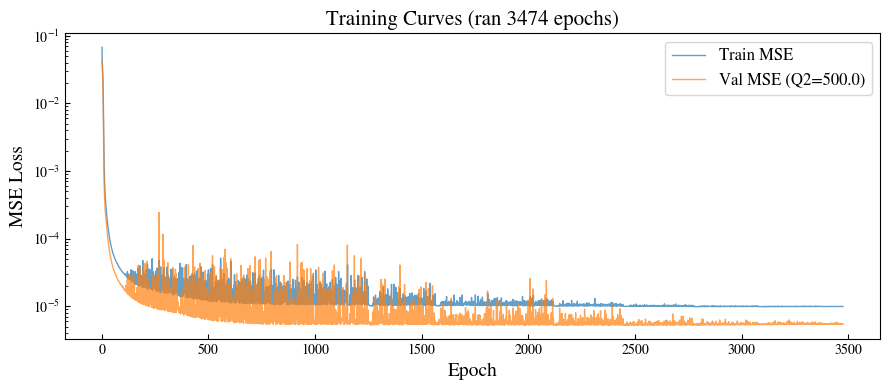

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_ran = len(train_losses)
ax.plot(range(1, epochs_ran + 1), train_losses, label='Train MSE', alpha=0.7, lw=1)
ax.plot(range(1, epochs_ran + 1), val_losses,   label=f'Val MSE (Q2={VAL_Q2})', alpha=0.7, lw=1)
ax.set_yscale('log')
ax.set_xlabel('Epoch', size=14)
ax.set_ylabel('MSE Loss', size=14)
ax.set_title(f'Training Curves (ran {epochs_ran} epochs)', size=15)
ax.legend(fontsize=12)
ax.tick_params(direction='in', which='both')
plt.tight_layout()
plt.savefig('training_curves.pdf', bbox_inches='tight')
plt.show()

## 7. Predictions vs Data
Each Q^2 has its own color.
Shaded bands = 95% replica intervals. Dashed = replica median. Solid = network prediction.
Crimson = held-out Q2=500 used for validation.

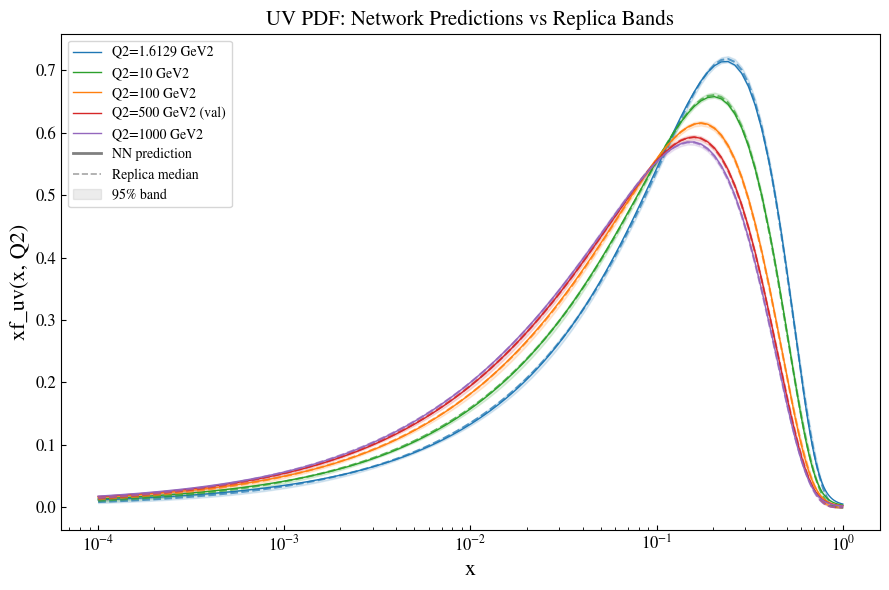

Plot saved to uv_pdf_all_Q2.pdf


In [ ]:
model.eval()
log_x_np = np.log(X)

colors = {
    1.6129: '#1f77b4',   # blue
    10:     '#2ca02c',   # green
    100:    '#ff7f0e',   # orange
    500:    '#d62728',   # crimson
    1000:   '#9467bd',   # purple
}

fig, ax = plt.subplots(figsize=(9, 6))

for q2 in Q2_vals:
    color     = colors[q2]
    val_label = ' (val)' if q2 == VAL_Q2 else ''

    # replica band
    uv     = treypdf[q2]['uv']
    lower  = np.quantile(uv, 0.025, axis=0)
    upper  = np.quantile(uv, 0.975, axis=0)
    median = np.median(uv, axis=0)
    ax.fill_between(X, lower, upper, alpha=0.15, color=color)
    ax.plot(X, median, color=color, lw=1.5, ls='--', alpha=0.7)

    # network prediction
    log_q2_np = np.full(N_x, np.log(q2))
    inp = torch.tensor(
        np.stack([log_x_np, log_q2_np], axis=1), dtype=torch.float32
    ).to(device)
    with torch.no_grad():
        pred = model(inp).cpu().numpy().flatten()
    ax.plot(X, pred, color=color, lw=1.0, label=f'Q2={q2} GeV2{val_label}')

# legend for line styles
ax.plot([], [], color='grey', lw=2,   ls='-',  label='NN prediction')
ax.plot([], [], color='grey', lw=1.2, ls='--', alpha=0.7, label='Replica median')
ax.fill_between([], [], [], alpha=0.15, color='grey', label='95% band')

ax.set_xscale('log')
ax.set_xlabel('x', size=16)
ax.set_ylabel('xf_uv(x, Q2)', size=16)
ax.set_title('UV PDF: Network Predictions vs Replica Bands', size=15)
ax.tick_params(direction='in', which='both', labelsize=12)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('uv_pdf_all_Q2.pdf', bbox_inches='tight')
plt.show()
print('Plot saved to uv_pdf_all_Q2.pdf')

## 8. Coverage Check
Fraction of x points where the network falls within the 95% replica band.

In [ ]:
model.eval()
log_x_np = np.log(X)
print('Coverage within 95% replica band:')
print(f'{"Q2 (GeV2)":>12} | {"Coverage":>10} | {"Val set":>8}')
print('-' * 38)

for q2 in Q2_vals:
    uv    = treypdf[q2]['uv']
    lower = np.quantile(uv, 0.025, axis=0)
    upper = np.quantile(uv, 0.975, axis=0)

    log_q2_np = np.full(N_x, np.log(q2))
    inp = torch.tensor(
        np.stack([log_x_np, log_q2_np], axis=1), dtype=torch.float32
    ).to(device)
    with torch.no_grad():
        pred = model(inp).cpu().numpy().flatten()

    inside = np.mean((pred >= lower) & (pred <= upper)) * 100
    is_val = 'YES' if q2 == VAL_Q2 else ''
    print(f'{q2:>12} | {inside:>9.1f}% | {is_val:>8}')

Coverage within 95% replica band:
   Q2 (GeV2) |   Coverage |  Val set
--------------------------------------
      1.6129 |      65.0% |         
          10 |      69.0% |         
         100 |      66.0% |         
         500 |      67.5% |      YES
        1000 |      68.0% |         


## 9. Save Model

In [ ]:
save_path = '/content/drive/MyDrive/uv_pdf_model.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'best_val_loss':    best_val_loss,
    'Q2_vals':          Q2_vals,
    'val_Q2':           VAL_Q2,
    'train_losses':     train_losses,
    'val_losses':       val_losses,
    'notes':            'MSE training on uv replicas — trey24_no_sidis_lo.npy'
}, save_path)
print(f'Saved to {save_path}')

Saved to /content/drive/MyDrive/uv_pdf_model.pt
